In [1]:
import pandas as pd

# Load the CSV file
file_path = "Taxi_Trips_2024.csv"
df = pd.read_csv(file_path)

df.rename(columns={'Dropoff Centroid  Location': 'Dropoff Centroid Location'}, inplace=True)

# Display the first few rows
print(df.head())

                                    Trip ID  \
0  0000184e7cd53cee95af32eba49c44e4d20adcd8   
1  000072ee076c9038868e239ca54185eb43959db0   
2  000074019d598c2b1d6e77fbae79e40b0461a2fc   
3  00007572c5f92e2ff067e6f838a5ad74e83665d3   
4  00007c3e7546e2c7d15168586943a9c22c3856cf   

                                             Taxi ID    Trip Start Timestamp  \
0  f538e6b729d1aaad4230e9dcd9dc2fd9a168826ddadbd6...  01/19/2024 05:00:00 PM   
1  e51e2c30caec952b40b8329a68b498e18ce8a1f40fa75c...  01/28/2024 02:30:00 PM   
2  aeb280ef3be3e27e081eb6e76027615b0d40925b84d3eb...  01/05/2024 09:00:00 AM   
3  7d21c2ca227db8f27dda96612bfe5520ab408fa9a462c8...  01/22/2024 08:45:00 AM   
4  8ef1056519939d511d24008e394f83e925d2539d668a00...  01/18/2024 07:15:00 PM   

       Trip End Timestamp  Trip Seconds  Trip Miles  Pickup Census Tract  \
0  01/19/2024 06:00:00 PM        4051.0       17.12         1.703198e+10   
1  01/28/2024 03:00:00 PM        1749.0       12.70                  NaN   
2  01/05

In [2]:
import warnings
warnings.simplefilter(action='ignore')

## List Variables and Data Types

In [3]:
# Display a summary of the dataset
print("Dataset Summary:")
print(df.info())

Dataset Summary:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6480364 entries, 0 to 6480363
Data columns (total 23 columns):
 #   Column                      Dtype  
---  ------                      -----  
 0   Trip ID                     object 
 1   Taxi ID                     object 
 2   Trip Start Timestamp        object 
 3   Trip End Timestamp          object 
 4   Trip Seconds                float64
 5   Trip Miles                  float64
 6   Pickup Census Tract         float64
 7   Dropoff Census Tract        float64
 8   Pickup Community Area       float64
 9   Dropoff Community Area      float64
 10  Fare                        float64
 11  Tips                        float64
 12  Tolls                       float64
 13  Extras                      float64
 14  Trip Total                  float64
 15  Payment Type                object 
 16  Company                     object 
 17  Pickup Centroid Latitude    float64
 18  Pickup Centroid Longitude   float64
 19  Pick

In [4]:
# Adjust sample percentage (e.g., 10% or 20%)
sample_percentage = 0.2  # 0.2 for 20%
sampled_df = df.sample(frac=sample_percentage, random_state=42).reset_index(drop=True)

# Check the size of the sampled dataset
print(f"Original dataset size: {df.shape}")
print(f"Sampled dataset size: {sampled_df.shape}")


Original dataset size: (6480364, 23)
Sampled dataset size: (1296073, 23)


## Handle Missing Values

In [5]:
# Fill missing numeric values with the median
numeric_cols = ['Trip Seconds', 'Trip Miles', 'Trip Total', 'Extras', 'Tips', 'Tolls', 'Fare']
sampled_df[numeric_cols] = sampled_df[numeric_cols].fillna(sampled_df[numeric_cols].median())

# Fill missing categorical values with 'Unknown'
categorical_cols = ['Payment Type', 'Company']
sampled_df[categorical_cols] = sampled_df[categorical_cols].fillna('Unknown')

# Drop rows with missing critical location values (latitudes/longitudes)
sampled_df = sampled_df.dropna(subset=['Pickup Centroid Latitude', 'Pickup Centroid Longitude', 
                                       'Dropoff Centroid Latitude', 'Dropoff Centroid Longitude'])


In [6]:
sampled_df['Pickup Census Tract'] = sampled_df['Pickup Census Tract'].fillna(0)
sampled_df['Dropoff Census Tract'] = sampled_df['Dropoff Census Tract'].fillna(0)
sampled_df['Pickup Community Area'] = sampled_df['Pickup Community Area'].fillna(sampled_df['Pickup Community Area'].mode()[0])
sampled_df['Dropoff Community Area'] = sampled_df['Dropoff Community Area'].fillna(sampled_df['Dropoff Community Area'].mode()[0])

In [7]:
print("Missing Values After Further Cleaning:")
print(sampled_df.isnull().sum())

Missing Values After Further Cleaning:
Trip ID                       0
Taxi ID                       0
Trip Start Timestamp          0
Trip End Timestamp            0
Trip Seconds                  0
Trip Miles                    0
Pickup Census Tract           0
Dropoff Census Tract          0
Pickup Community Area         0
Dropoff Community Area        0
Fare                          0
Tips                          0
Tolls                         0
Extras                        0
Trip Total                    0
Payment Type                  0
Company                       0
Pickup Centroid Latitude      0
Pickup Centroid Longitude     0
Pickup Centroid Location      0
Dropoff Centroid Latitude     0
Dropoff Centroid Longitude    0
Dropoff Centroid Location     0
dtype: int64


In [8]:
print(f"Final cleaned dataset size: {sampled_df.shape}")

Final cleaned dataset size: (1170268, 23)


In [9]:
# Define numeric columns to check for outliers
numeric_cols = ['Trip Miles', 'Trip Seconds', 'Trip Total']

# Detect and remove outliers using IQR
for col in numeric_cols:
    q1 = sampled_df[col].quantile(0.25)  # First quartile
    q3 = sampled_df[col].quantile(0.75)  # Third quartile
    iqr = q3 - q1  # Interquartile range
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    sampled_df = sampled_df[(sampled_df[col] >= lower_bound) & (sampled_df[col] <= upper_bound)]

# Check dataset size after removing outliers
print(f"Dataset size after outlier removal: {sampled_df.shape}")

Dataset size after outlier removal: (1105495, 23)


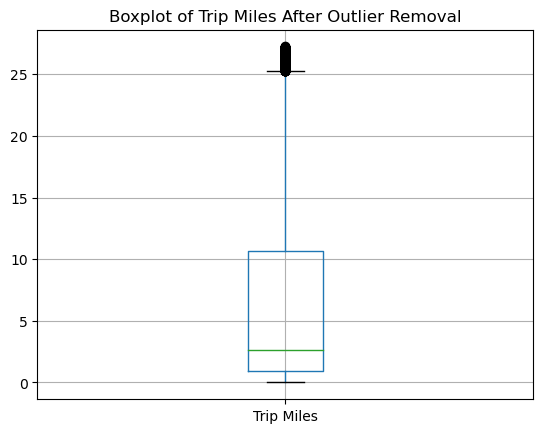

In [10]:
import matplotlib.pyplot as plt

# Boxplot for Trip Miles
sampled_df.boxplot(column='Trip Miles')
plt.title('Boxplot of Trip Miles After Outlier Removal')
plt.show()

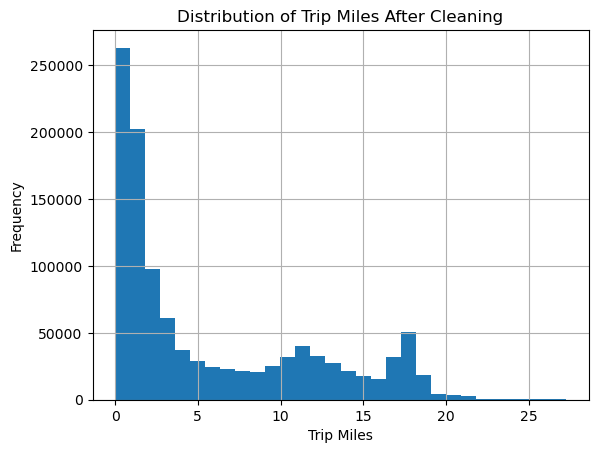

In [11]:
sampled_df['Trip Miles'].hist(bins=30)
plt.title("Distribution of Trip Miles After Cleaning")
plt.xlabel("Trip Miles")
plt.ylabel("Frequency")
plt.show()

Most trips are concentrated between 0 and 5 miles, which is expected for typical taxi rides in cities.
There’s a small but clear decline in trip frequency as distance increases, which makes sense since longer trips are less common.
The cleaning effectively removed outliers (e.g., extremely long trips) while retaining valid data up to 27.25 miles.


In [12]:
print(f"Trip Miles range after cleaning: {sampled_df['Trip Miles'].min()} to {sampled_df['Trip Miles'].max()}")

Trip Miles range after cleaning: 0.0 to 27.25


The range looks realistic, and it aligns with common expectations for taxi trips.

In [13]:
print(sampled_df['Trip Miles'].describe())

count    1.105495e+06
mean     5.748375e+00
std      6.073490e+00
min      0.000000e+00
25%      9.700000e-01
50%      2.600000e+00
75%      1.070000e+01
max      2.725000e+01
Name: Trip Miles, dtype: float64


In [14]:
# Standardize Payment Type and Company columns
sampled_df['Payment Type'] = sampled_df['Payment Type'].str.lower().str.strip()
sampled_df['Company'] = sampled_df['Company'].str.lower().str.strip()

# Check unique values to confirm consistency
print("Unique Payment Types:", sampled_df['Payment Type'].unique())
print("Unique Companies:", sampled_df['Company'].unique())

Unique Payment Types: ['mobile' 'credit card' 'cash' 'prcard' 'unknown' 'no charge' 'dispute']
Unique Companies: ['sun taxi' 'taxi affiliation services llc - yell' 'medallion leasin'
 'city service' '5 star taxi' 'tac - yellow cab association' 'flash cab'
 'taxicab insurance agency llc' 'blue ribbon taxi association'
 'taxi affiliation services' '3591 - 63480 chuks cab'
 'choice taxi association' 'chicago independents'
 'choice taxi association inc' 'u taxicab' 'globe taxi'
 'taxicab insurance agency, llc' '312 medallion management corp'
 'koam taxi association' 'patriot taxi dba peace taxi associat'
 'chicago city taxi association' 'tac - checker cab dispatch'
 'chicago taxicab' 'setare inc' 'wolley taxi' 'top cab'
 'tac - american united dispatch' '5167 - 71969 5167 taxi inc'
 'metro jet taxi a.' '3556 - 36214 rc andrews cab'
 'tac - blue diamond dispatch' '6574 - babylon express inc.'
 'star north taxi management llc' 'tac - yellow non color'
 '2733 - 74600 benny jona' 'petani cab c

## Numerical Columns
Negative or Zero Values: Columns like Trip Miles, Trip Seconds, or Trip Total should not have negative values.
Unrealistic Values: Extremely high or low values that fall outside the expected range.

In [15]:
# Check how many rows had Trip Miles = 0 in the original dataset
zero_miles_count = sampled_df[sampled_df['Trip Miles'] == 0].shape[0]
print(f"Number of rows with Trip Miles = 0: {zero_miles_count}")

Number of rows with Trip Miles = 0: 108209


In [16]:
# Add a Trip Status column
sampled_df['Trip Status'] = sampled_df['Trip Seconds'].apply(lambda x: 'Canceled' if x <= 0 else 'Completed')

# Verify the distribution of trip statuses
print(sampled_df['Trip Status'].value_counts())

Trip Status
Completed    1089833
Canceled       15662
Name: count, dtype: int64


## Categorical Columns
Inconsistent Categories: Columns like Payment Type and Company may have inconsistent or redundant entries (e.g., "credit card" vs. "Credit Card").
Unusual Values: Unexpected values like "unknown" or "dispute" in Payment Type.

In [17]:
# Check for unique values in categorical columns
print("Unique Payment Types:", sampled_df['Payment Type'].unique())
print("Unique Companies:", sampled_df['Company'].unique())

Unique Payment Types: ['mobile' 'credit card' 'cash' 'prcard' 'unknown' 'no charge' 'dispute']
Unique Companies: ['sun taxi' 'taxi affiliation services llc - yell' 'medallion leasin'
 'city service' '5 star taxi' 'tac - yellow cab association' 'flash cab'
 'taxicab insurance agency llc' 'blue ribbon taxi association'
 'taxi affiliation services' '3591 - 63480 chuks cab'
 'choice taxi association' 'chicago independents'
 'choice taxi association inc' 'u taxicab' 'globe taxi'
 'taxicab insurance agency, llc' '312 medallion management corp'
 'koam taxi association' 'patriot taxi dba peace taxi associat'
 'chicago city taxi association' 'tac - checker cab dispatch'
 'chicago taxicab' 'setare inc' 'wolley taxi' 'top cab'
 'tac - american united dispatch' '5167 - 71969 5167 taxi inc'
 'metro jet taxi a.' '3556 - 36214 rc andrews cab'
 'tac - blue diamond dispatch' '6574 - babylon express inc.'
 'star north taxi management llc' 'tac - yellow non color'
 '2733 - 74600 benny jona' 'petani cab c

In [18]:
# Check for unrealistic values
print(sampled_df[['Trip Miles', 'Trip Seconds', 'Trip Total']].describe())

# Optional filter for overly long trips
sampled_df = sampled_df[sampled_df['Trip Seconds'] < 36000]  # Remove trips > 10 hours

         Trip Miles  Trip Seconds    Trip Total
count  1.105495e+06  1.105495e+06  1.105495e+06
mean   5.748375e+00  1.078288e+03  2.335693e+01
std    6.073490e+00  8.168097e+02  1.756876e+01
min    0.000000e+00  0.000000e+00  0.000000e+00
25%    9.700000e-01  4.550000e+02  1.000000e+01
50%    2.600000e+00  8.410000e+02  1.590000e+01
75%    1.070000e+01  1.560000e+03  3.275000e+01
max    2.725000e+01  3.498000e+03  7.062000e+01


1. **Short Trips Dominate**:
   - Most trips are between **0 and 5 miles**, with a large concentration around **1-2 miles**.
   - The average trip distance is **5.74 miles**, but 50% of trips are shorter than **3.46 miles**.

2. **Skewed Distribution**:
   - The histogram is **right-skewed**, indicating that while most trips are short, a few longer trips (up to **27.25 miles**) exist.

3. **Variability**:
   - The standard deviation of **6.29 miles** shows that trip distances vary widely, though most are within **10 miles**.

4. **Zero-Mile Trips**:
   - The presence of trips with **0 miles** suggests potential canceled trips or data issues that need further review.

This distribution aligns with typical urban taxi operations, where shorter trips are more common, and longer trips are rare.

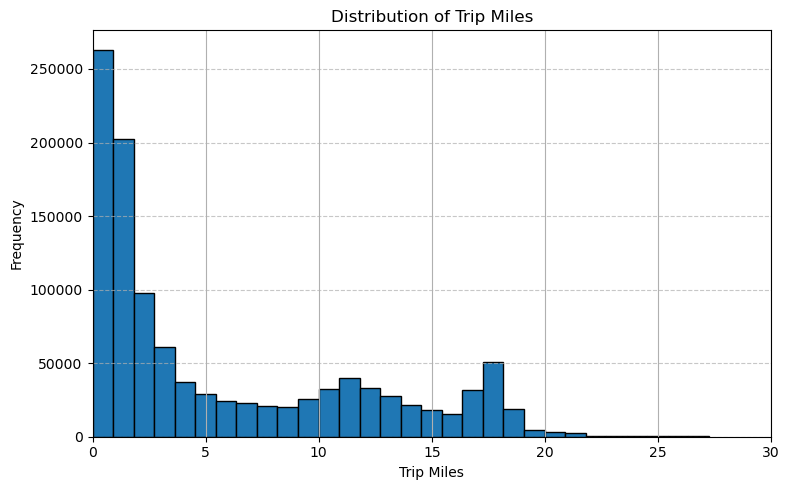

In [19]:
import matplotlib.pyplot as plt

# Adjust figure size and add axis limits
plt.figure(figsize=(8, 5))  # Smaller figure size if needed
plt.xlim(0, 30)  # Limit the x-axis to focus on meaningful data range

# Plot histogram for Trip Miles
sampled_df['Trip Miles'].hist(bins=30, edgecolor='black')
plt.title('Distribution of Trip Miles')
plt.xlabel('Trip Miles')
plt.ylabel('Frequency')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()  # Ensure the plot fits well in the output area
plt.show()


1. **Most Trips Are Short**:
   - The majority of trips fall in the **0–5 miles** range, with the highest frequency around **1–2 miles**. This aligns with typical city taxi operations, where short, local trips are common.

2. **Longer Trips Are Rare**:
   - Beyond **5 miles**, the frequency of trips declines sharply. Trips exceeding **15 miles** are uncommon.

3. **Right-Skewed Distribution**:
   - The histogram shows a **long tail**, indicating a small number of longer trips, while most trips are clustered in the shorter distance range.

4. **Urban Taxi Behavior**:
   - The data reflects typical urban travel patterns, dominated by short-distance trips like commuting or errands. Rare long trips might be exceptions, such as airport transfers or inter-city trips.

This summary highlights that the dataset aligns with expectations for urban taxi services.

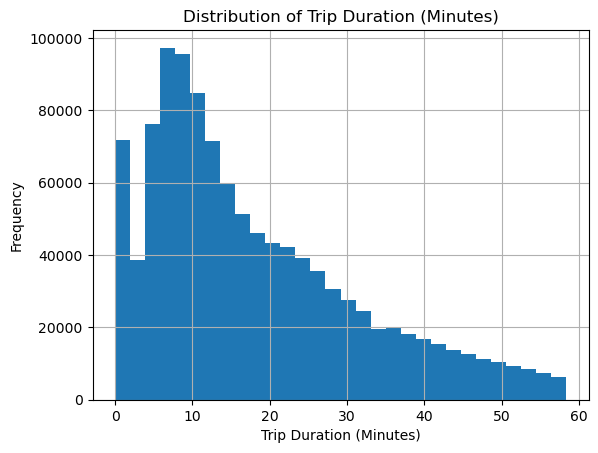

In [20]:
# Convert Trip Seconds to Minutes for better readability
sampled_df['Trip Duration (minutes)'] = sampled_df['Trip Seconds'] / 60

# Plot histogram for Trip Duration
sampled_df['Trip Duration (minutes)'].hist(bins=30)
plt.title('Distribution of Trip Duration (Minutes)')
plt.xlabel('Trip Duration (Minutes)')
plt.ylabel('Frequency')
plt.show()

<b> Most Trips Are Short: </b>

The majority of trips last between 5–20 minutes, with the highest frequency around 10 minutes.
This aligns with the behavior of urban taxi services, where short-duration trips are more common.
Decline in Longer Durations:

After 20 minutes, the frequency of trips steadily decreases.
Very few trips last longer than 40 minutes.

Right-Skewed Distribution: The histogram is right-skewed, with a long tail toward higher durations, indicating that while longer trips exist, they are rare.

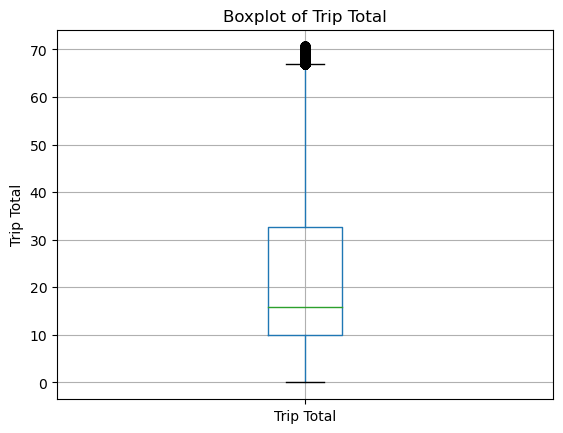

In [21]:
# Boxplot for Trip Total
sampled_df.boxplot(column='Trip Total')
plt.title('Boxplot of Trip Total')
plt.ylabel('Trip Total')
plt.show()

<b> Median (Green Line): </b>

The median trip total (middle line of the box) is around $15–20, indicating that half of the trips cost less than this amount.

<b> Interquartile Range (Box): </b>

The box represents the middle 50% of the data (between the 25th percentile and the 75th percentile).
Most trip totals fall within $10 to $32.7, indicating that the majority of trips are reasonably priced.

<b> Whiskers: </b>

The whiskers extend to the minimum and maximum non-outlier values.
The lower whisker starts close to $0, while the upper whisker ends just above $60.

<b> Outliers (Black Dots): </b>

There are a few outliers above $60, representing unusually high trip totals. These could be due to long trips, high tips, or other surcharges.

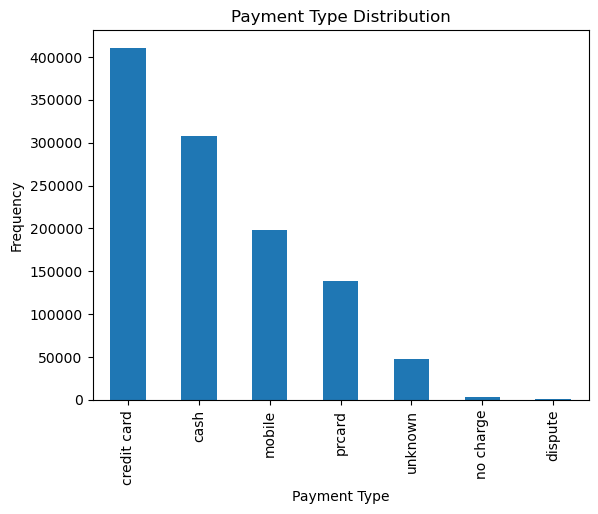

In [22]:
# Plot bar chart for Payment Type
sampled_df['Payment Type'].value_counts().plot(kind='bar')
plt.title('Payment Type Distribution')
plt.xlabel('Payment Type')
plt.ylabel('Frequency')
plt.show()

In [23]:
rare_categories = sampled_df[sampled_df['Payment Type'].isin(['dispute', 'unknown', 'no charge'])]
print(rare_categories[['Trip Miles', 'Trip Total', 'Company']])

         Trip Miles  Trip Total                    Company
17             11.6       38.50  taxi affiliation services
54              7.7       27.75  taxi affiliation services
76              8.6       24.25  taxi affiliation services
82             10.9       29.00  taxi affiliation services
119             9.5       26.00  taxi affiliation services
...             ...         ...                        ...
1295964         3.6       12.00  taxi affiliation services
1295982        10.7       28.50  taxi affiliation services
1295988         9.3       26.00  taxi affiliation services
1296012         2.6       12.25  taxi affiliation services
1296024         3.2       12.00  taxi affiliation services

[51012 rows x 3 columns]


In [24]:
sampled_df.groupby('Payment Type')['Trip Total'].mean().sort_values(ascending=False)

Payment Type
credit card    31.070935
prcard         24.662570
unknown        23.732102
mobile         19.466244
dispute        15.557977
cash           15.018237
no charge      13.543587
Name: Trip Total, dtype: float64

Credit card payments have the highest average trip total at $ 31.04, indicating that passengers paying by card tend to take longer or higher-cost trips.

Prcard payments (possibly prepaid cards) are the second-highest at $ 24.61.

Unknown payments have an average of $ 23.73, which could reflect data errors or less frequent payment types.

Mobile, cash, and dispute payments have progressively lower averages, with cash averaging just $ 15.62.

No charge payments average $ 13.71, likely reflecting promotional or free rides.

<b>Credit Cards Dominate:</b>

The most frequent payment method is credit card, with over 175,000 trips paid this way. This suggests that most passengers prefer electronic payments, possibly due to convenience.

<b>Cash as the Second Choice:</b>

Cash is the second most common payment type, with a significant number of trips paid this way, indicating that a portion of passengers still prefer traditional methods.

<b>Mobile Payments and Others:</b>

Mobile payments also have a noticeable share, likely reflecting an increasing trend toward digital wallets.
Prcard, unknown, and no charge are less frequent, which could indicate errors, unusual payment methods, or specific cases (e.g., promotional rides or disputes).

<b>Unusual Categories:</b>

Categories like dispute and no charge are very rare, suggesting exceptional cases such as payment issues or free rides.

<b>Distance as the Key Driver of Cost:</b>
Trip Miles has the strongest correlation with Trip Total, indicating that distance is the primary determinant of trip cost.

<b>Secondary Role of Time:</b>
Trip Seconds also influences cost, though less strongly than distance. This might reflect fare structures that include both distance-based and time-based components.

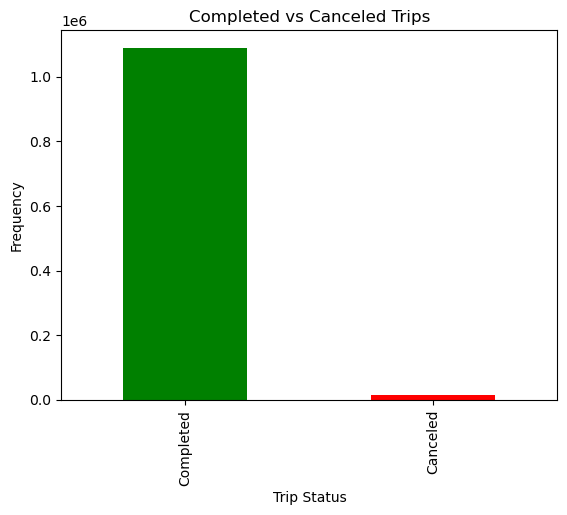

In [25]:
sampled_df['Trip Status'].value_counts().plot(kind='bar', color=['green', 'red'])
plt.title('Completed vs Canceled Trips')
plt.xlabel('Trip Status')
plt.ylabel('Frequency')
plt.show()

<b>Most Trips Are Completed:</b>

The vast majority of trips are completed (represented by the green bar). This indicates efficient taxi operations with a very low cancellation rate.

<b>Few Canceled Trips:</b>

A small number of trips are marked as canceled (red bar). This aligns with the expectations for urban taxi services, where cancellations are uncommon.

In [26]:
# Convert Trip Start Timestamp to datetime
sampled_df['Trip Start Timestamp'] = pd.to_datetime(sampled_df['Trip Start Timestamp'], errors='coerce')

In [27]:
# Extract the hour from Trip Start Timestamp
sampled_df['Trip Start Hour'] = sampled_df['Trip Start Timestamp'].dt.hour

In [28]:
print(sampled_df[['Trip Start Timestamp', 'Trip Start Hour']].head())

  Trip Start Timestamp  Trip Start Hour
1  2024-08-08 12:00:00               12
2  2024-01-18 08:00:00                8
3  2024-10-18 09:15:00                9
4  2024-09-23 09:45:00                9
5  2024-12-05 13:30:00               13


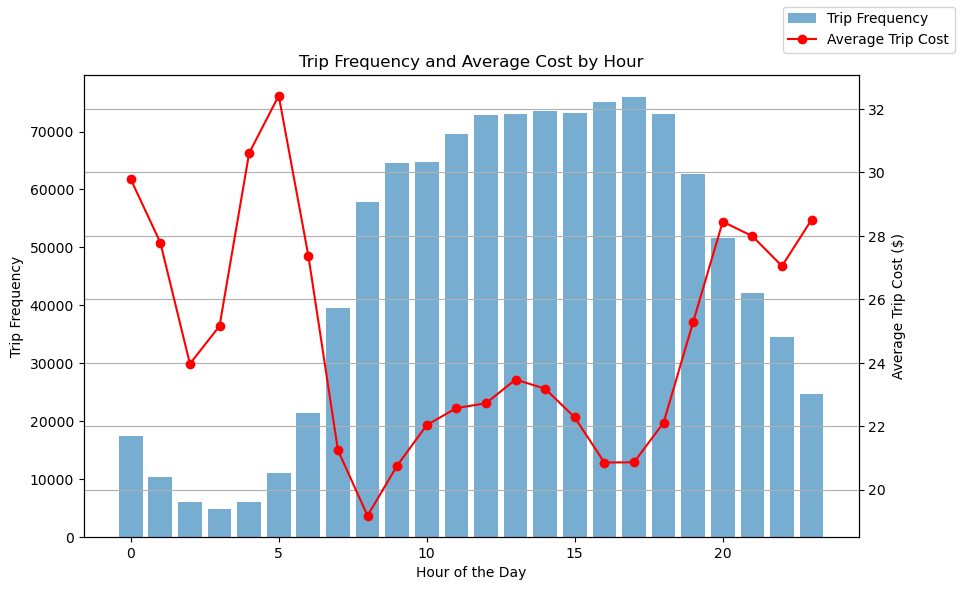

In [29]:
# Calculate trip frequency by hour
hourly_trip_frequency = sampled_df['Trip Start Hour'].value_counts().sort_index()

# Calculate average trip cost by hour
hourly_trip_cost = sampled_df.groupby('Trip Start Hour')['Trip Total'].mean().reset_index()

# Plot trip frequency (bar chart) and average trip cost (line chart)
import matplotlib.pyplot as plt

fig, ax1 = plt.subplots(figsize=(10, 6))

# Plot trip frequency as bar chart
ax1.bar(hourly_trip_frequency.index, hourly_trip_frequency.values, alpha=0.6, label='Trip Frequency')
ax1.set_xlabel('Hour of the Day')
ax1.set_ylabel('Trip Frequency')
ax1.set_title('Trip Frequency and Average Cost by Hour')

# Plot average trip cost as line chart
ax2 = ax1.twinx()
ax2.plot(hourly_trip_cost['Trip Start Hour'], hourly_trip_cost['Trip Total'], color='red', marker='o', label='Average Trip Cost')
ax2.set_ylabel('Average Trip Cost ($)')

fig.legend(loc='upper right')
plt.grid(True)
plt.show()

<b>Demand Patterns:</b>

Peak demand is during 7 AM - 10 AM and 4 PM - 8 PM.
Businesses should allocate more taxis during these hours to meet demand.

<b>Revenue Opportunities:</b>

Despite fewer trips, the midnight to early morning period yields higher revenue per trip, suggesting a focus on long-distance or premium rides during these hours.

<b>Customer Behavior:</b>

Commuters dominate during peak hours, resulting in lower average costs due to shorter trips.
Leisure or long-distance travelers dominate late-night and early-morning hours, increasing average trip costs.

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt

# Ensure 'Pickup Community Area' and 'Dropoff Community Area' are not missing
community_data = sampled_df.dropna(subset=['Pickup Community Area', 'Dropoff Community Area'])

# Create an edge list for the network
edges = community_data.groupby(['Pickup Community Area', 'Dropoff Community Area']).size().reset_index(name='Trip Count')

# Initialize a directed graph
G = nx.DiGraph()

# Add edges to the graph
for _, row in edges.iterrows():
    G.add_edge(row['Pickup Community Area'], row['Dropoff Community Area'], weight=row['Trip Count'])

# Plot the network with a smaller figure size
plt.figure(figsize=(8, 8))  # Adjusted figure size for smaller visualization

# Define node sizes based on their degree (in + out connections)
node_sizes = [50 * G.degree(node) for node in G.nodes()]  # Reduced node size for compact view

# Draw the network
pos = nx.spring_layout(G, seed=42, k=0.3)  # Adjust layout spacing for smaller graph
nx.draw_networkx_nodes(G, pos, node_size=node_sizes, node_color='skyblue', alpha=0.7)
nx.draw_networkx_edges(G, pos, edge_color='gray', alpha=0.5, width=0.5)  # Reduced edge width
nx.draw_networkx_labels(G, pos, font_size=8)  # Smaller font size for labels

# Add edge labels for trip counts
edge_labels = {(u, v): d['weight'] for u, v, d in G.edges(data=True)}
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=6)  # Smaller edge label font

# Customize the plot
plt.title("Community Area Interaction Network", fontsize=12)  # Smaller title font size
plt.tight_layout()  # Ensure the layout fits snugly
plt.show()

<b>What are the most connected community areas in terms of taxi trip traffic, and how are different community areas interconnected?</b>

This includes identifying:

High-demand community areas (hubs) with significant traffic (largest nodes).
Major flow corridors between community areas (thick or prominent edges).
Spatial connectivity patterns, highlighting areas with high interaction versus isolated regions.
It provides actionable insights into urban transportation dynamics and network centrality of locations.

In [ ]:
# Calculate the degree of each node (total connections)
degree_dict = dict(G.degree())

# Sort nodes by degree in descending order to find busiest areas
busiest_areas = sorted(degree_dict.items(), key=lambda x: x[1], reverse=True)

# Display top 5 busiest areas
print("Top 5 Busiest Community Areas:")
for area, degree in busiest_areas[:5]:
    print(f"Community Area {area} with {degree} connections")

# Display top 5 least busy areas
print("\nTop 5 Least Busy Community Areas:")
for area, degree in busiest_areas[-5:]:
    print(f"Community Area {area} with {degree} connections")

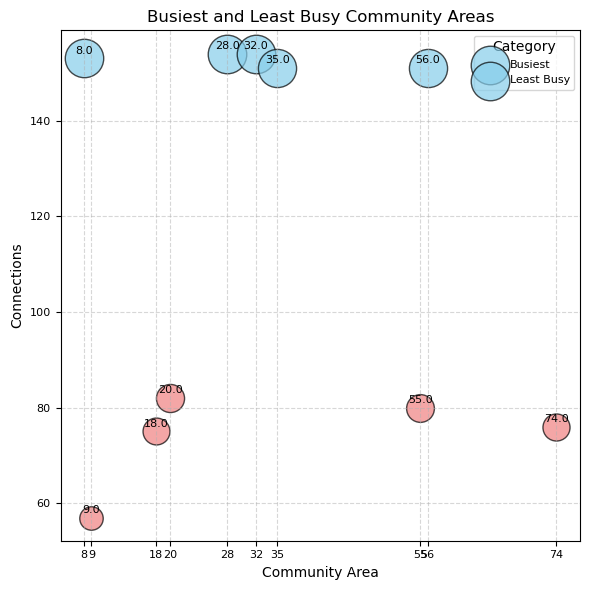

In [32]:
import matplotlib.pyplot as plt

# Extract data for busiest and least busy areas
top_busiest = busiest_areas[:5]
top_least_busy = busiest_areas[-5:]

# Combine data
areas = [area for area, _ in top_busiest] + [area for area, _ in top_least_busy]
connections = [degree for _, degree in top_busiest] + [degree for _, degree in top_least_busy]
categories = ['Busiest'] * len(top_busiest) + ['Least Busy'] * len(top_least_busy)

# Create a smaller bubble chart
plt.figure(figsize=(6, 6))  # Adjusted figure size for compact visualization

# Plot bubbles for each category
for area, degree, category in zip(areas, connections, categories):
    color = 'skyblue' if category == 'Busiest' else 'lightcoral'
    plt.scatter(area, degree, s=degree * 5, color=color, alpha=0.7, edgecolor='black')  # Reduced bubble size

# Add labels for points
for area, degree in zip(areas, connections):
    plt.text(area, degree + 1, f'{area}', fontsize=8, ha='center', color='black')  # Smaller text size

# Customize plot
plt.title('Busiest and Least Busy Community Areas', fontsize=12)  # Smaller title
plt.xlabel('Community Area', fontsize=10)
plt.ylabel('Connections', fontsize=10)
plt.grid(axis='both', linestyle='--', alpha=0.5)
plt.xticks(areas, fontsize=8)  # Smaller tick labels
plt.yticks(fontsize=8)  # Smaller y-axis tick labels

# Add legend
plt.legend(['Busiest', 'Least Busy'], title='Category', fontsize=8, loc='upper right')

# Tight layout for compact fit
plt.tight_layout()
plt.show()

<b>Top (blue bubbles)</b>: The largest and highest bubbles represent the busiest community areas (e.g., areas 28.0, 8.0, and 32.0) with the most taxi activity.

<b>Bottom (red bubbles)</b>: The smaller and lower bubbles represent the least busy areas (e.g., areas 9.0, 74.0, and 18.0) with minimal taxi connections.

In short, it shows which areas have the most and least taxi traffic based on the number of connections.

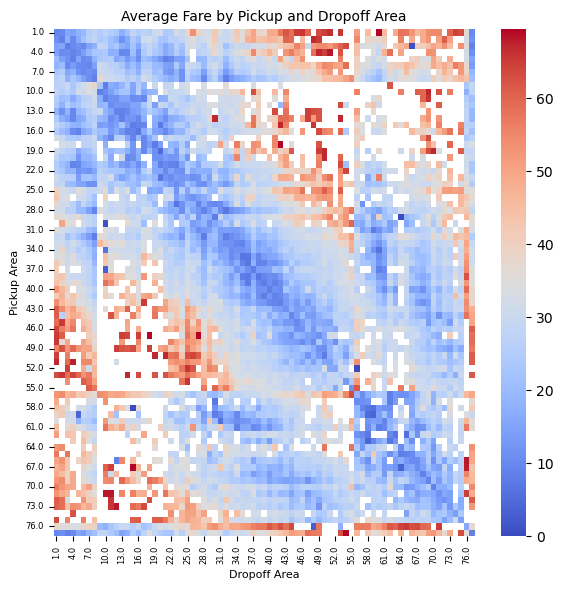

In [33]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Filter data to ensure community areas and fares are valid
fare_data = sampled_df.dropna(subset=['Pickup Community Area', 'Dropoff Community Area', 'Fare'])

# Group data by Pickup and Dropoff Community Areas to calculate average fare
heatmap_data = (
    fare_data.groupby(['Pickup Community Area', 'Dropoff Community Area'])['Fare']
    .mean()
    .unstack()
)

# Plot the heatmap with a smaller figure size
plt.figure(figsize=(6, 6))  # Reduced figure size for compact visualization
sns.heatmap(heatmap_data, cmap='coolwarm', annot=False, cbar=True, square=False)

# Customize the plot
plt.title("Average Fare by Pickup and Dropoff Area", fontsize=10)  # Smaller title
plt.xlabel("Dropoff Area", fontsize=8)
plt.ylabel("Pickup Area", fontsize=8)
plt.xticks(fontsize=6)  # Smaller x-axis labels
plt.yticks(fontsize=6)  # Smaller y-axis labels
plt.tight_layout()  # Ensure everything fits neatly
plt.show()

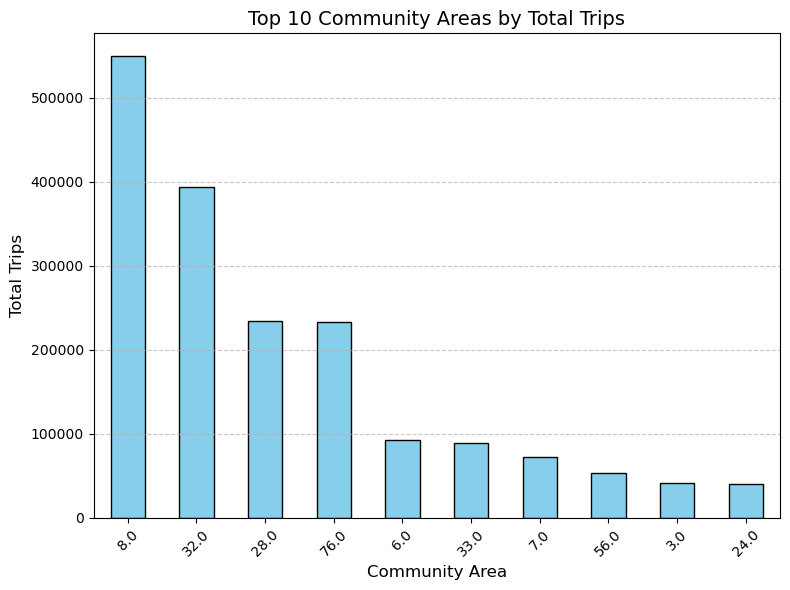

In [34]:
import matplotlib.pyplot as plt

# Combine pickup and dropoff data to calculate total trip activity per community area
pickup_counts = sampled_df['Pickup Community Area'].value_counts()
dropoff_counts = sampled_df['Dropoff Community Area'].value_counts()
total_counts = pickup_counts.add(dropoff_counts, fill_value=0)

# Get the top 10 community areas with the most trips
top_10_areas = total_counts.nlargest(10)

# Plot the bar chart
plt.figure(figsize=(8, 6))
top_10_areas.plot(kind='bar', color='skyblue', edgecolor='black')

# Customize the plot
plt.title('Top 10 Community Areas by Total Trips', fontsize=14)
plt.xlabel('Community Area', fontsize=12)
plt.ylabel('Total Trips', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Show the plot
plt.tight_layout()
plt.show()

In [35]:
print(df.columns)

Index(['Trip ID', 'Taxi ID', 'Trip Start Timestamp', 'Trip End Timestamp',
       'Trip Seconds', 'Trip Miles', 'Pickup Census Tract',
       'Dropoff Census Tract', 'Pickup Community Area',
       'Dropoff Community Area', 'Fare', 'Tips', 'Tolls', 'Extras',
       'Trip Total', 'Payment Type', 'Company', 'Pickup Centroid Latitude',
       'Pickup Centroid Longitude', 'Pickup Centroid Location',
       'Dropoff Centroid Latitude', 'Dropoff Centroid Longitude',
       'Dropoff Centroid Location'],
      dtype='object')


In [36]:
print(df[['Pickup Centroid Location', 'Dropoff Centroid Location']].head())

               Pickup Centroid Location             Dropoff Centroid Location
0  POINT (-87.9030396611 41.9790708201)  POINT (-87.6209929134 41.8849871918)
1  POINT (-87.6559981815 41.9442266014)                                   NaN
2  POINT (-87.6559981815 41.9442266014)   POINT (-87.6333080367 41.899602111)
3   POINT (-87.913624596 41.9802643146)                                   NaN
4  POINT (-87.6327464887 41.8809944707)  POINT (-87.6327464887 41.8809944707)


In [37]:
# Parse Pickup Centroid Location
df['Pickup Longitude'] = df['Pickup Centroid Location'].str.extract(r'\(([^ ]+)')[0].astype(float)
df['Pickup Latitude'] = df['Pickup Centroid Location'].str.extract(r' ([^ ]+)\)')[0].astype(float)

# Parse Dropoff Centroid Location
df['Dropoff Longitude'] = df['Dropoff Centroid Location'].str.extract(r'\(([^ ]+)')[0]
df['Dropoff Latitude'] = df['Dropoff Centroid Location'].str.extract(r' ([^ ]+)\)')[0]

# Convert to float and handle NaN
df['Dropoff Longitude'] = pd.to_numeric(df['Dropoff Longitude'], errors='coerce')
df['Dropoff Latitude'] = pd.to_numeric(df['Dropoff Latitude'], errors='coerce')

# Display parsed data
print(df[['Pickup Longitude', 'Pickup Latitude', 'Dropoff Longitude', 'Dropoff Latitude']].head())

   Pickup Longitude  Pickup Latitude  Dropoff Longitude  Dropoff Latitude
0        -87.903040        41.979071         -87.620993         41.884987
1        -87.655998        41.944227                NaN               NaN
2        -87.655998        41.944227         -87.633308         41.899602
3        -87.913625        41.980264                NaN               NaN
4        -87.632746        41.880994         -87.632746         41.880994


In [38]:
# pip install geopy 

In [39]:
def reverse_geocode(lat, lon):
    try:
        if pd.notna(lat) and pd.notna(lon):  # Ensure coordinates are not NaN
            location = geolocator.reverse((lat, lon), timeout=10)
            if location:
                print(f"Resolved: ({lat}, {lon}) -> {location.address}")
            else:
                print(f"Could not resolve: ({lat}, {lon})")
            return location.address if location else None
        else:
            print(f"Skipping: ({lat}, {lon}) - Missing coordinates")
            return None
    except GeocoderTimedOut:
        print(f"Timeout for: ({lat}, {lon})")
        return None

In [40]:
from geopy.geocoders import Nominatim
from geopy.exc import GeocoderTimedOut
import pandas as pd

# Initialize the geolocator
geolocator = Nominatim(user_agent="geoapi")

# Define a function for reverse geocoding with error handling
def reverse_geocode(lat, lon):
    try:
        if pd.notna(lat) and pd.notna(lon):  # Ensure coordinates are not NaN
            location = geolocator.reverse((lat, lon), timeout=10)
            if location:
                print(f"Resolved: ({lat}, {lon}) -> {location.address}")
            else:
                print(f"Could not resolve: ({lat}, {lon})")
            return location.address if location else None
        else:
            print(f"Skipping: ({lat}, {lon}) - Missing coordinates")
            return None
    except GeocoderTimedOut:
        print(f"Timeout for: ({lat}, {lon})")
        return None

# Load the CSV file
file_path = "Taxi_Trips_2024.csv"
df = pd.read_csv(file_path)

# Take a sample of the data for testing (5 random rows)
df_sample = df.sample(5, random_state=42)

# Reverse geocode for pickup locations
df_sample['Pickup Address'] = df_sample.apply(
    lambda row: reverse_geocode(row['Pickup Centroid Latitude'], row['Pickup Centroid Longitude']), axis=1
)

# Reverse geocode for dropoff locations
df_sample['Dropoff Address'] = df_sample.apply(
    lambda row: reverse_geocode(row['Dropoff Centroid Latitude'], row['Dropoff Centroid Longitude']), axis=1
)

# Display the result for the sample
print(df_sample[['Pickup Centroid Latitude', 'Pickup Centroid Longitude', 'Pickup Address',
                 'Dropoff Centroid Latitude', 'Dropoff Centroid Longitude', 'Dropoff Address']])

Resolved: (41.97907082, -87.903039661) -> O'Hare Arrivals Terminal 3, O'Hare, Chicago, Jefferson Township, Cook County, Illinois, 60666, United States
Resolved: (41.899602111, -87.633308037) -> Moody Bible Institute, 820, North LaSalle Drive, River North, Near North Side, Chicago, Cook County, Illinois, 60610, United States
Resolved: (41.885300022, -87.642808466) -> 156, North Jefferson Street, Fulton River District, Near West Side, Chicago, West Chicago Township, Cook County, Illinois, 60606, United States
Resolved: (41.885300022, -87.642808466) -> 156, North Jefferson Street, Fulton River District, Near West Side, Chicago, West Chicago Township, Cook County, Illinois, 60606, United States
Resolved: (41.89503345, -87.619710672) -> Simpson Querrey Biomedical Research Center, 302, East Huron Street, Streeterville, Near North Side, Chicago, Cook County, Illinois, 60611, United States
Resolved: (41.892507781, -87.626214906) -> Rush-Ohio-Wabash Self Park, 50, East Ohio Street, River North,

In [41]:
pip install folium

Note: you may need to restart the kernel to use updated packages.


In [42]:
pip install --upgrade threadpoolctl scikit-learn

Note: you may need to restart the kernel to use updated packages.


         Pickup Centroid Latitude  Pickup Centroid Longitude  \
6440574                 41.979071                 -87.903040   
3573030                 41.899602                 -87.633308   
61009                   41.885300                 -87.642808   
4964379                 41.885300                 -87.642808   
4735605                 41.895033                 -87.619711   

                                            Pickup Address  \
6440574  O'Hare Arrivals Terminal 3, O'Hare, Chicago, J...   
3573030  Moody Bible Institute, 820, North LaSalle Driv...   
61009    156, North Jefferson Street, Fulton River Dist...   
4964379  156, North Jefferson Street, Fulton River Dist...   
4735605  Simpson Querrey Biomedical Research Center, 30...   

         Dropoff Centroid Latitude  Dropoff Centroid Longitude  \
6440574                  41.892508                  -87.626215   
3573030                  41.812949                  -87.617860   
61009                    41.880994          

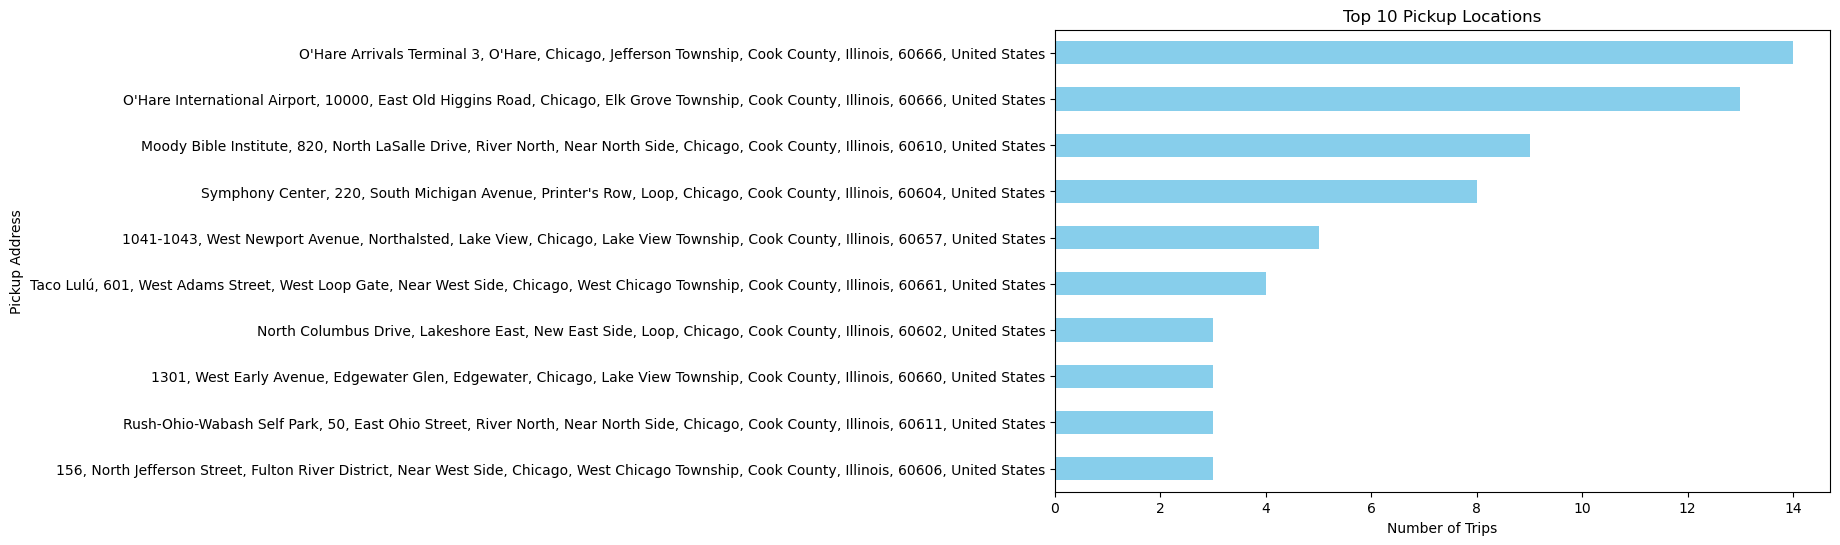

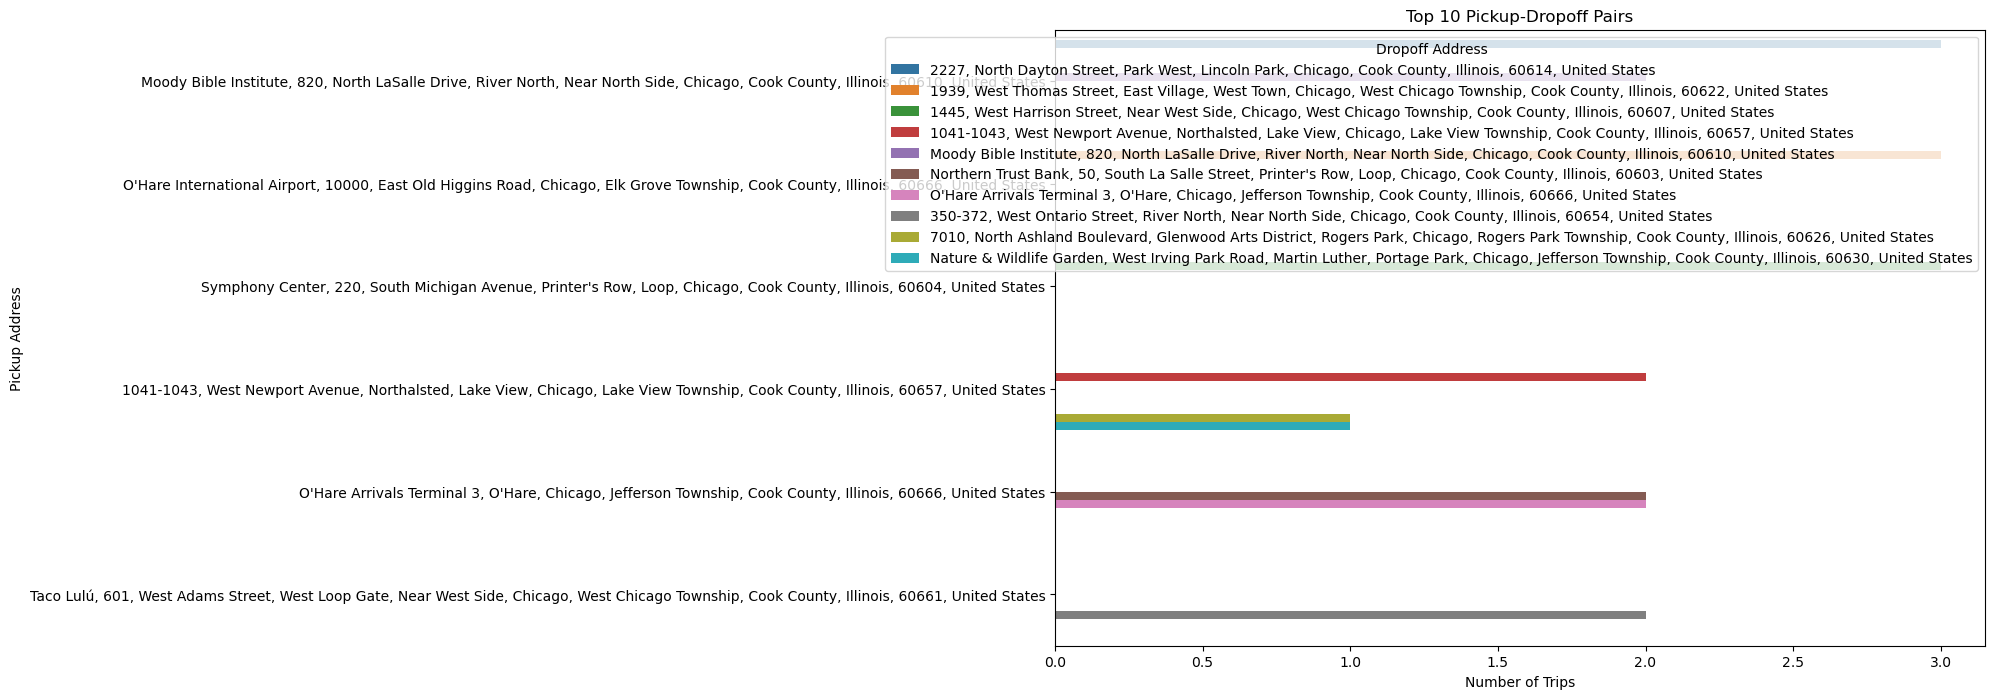

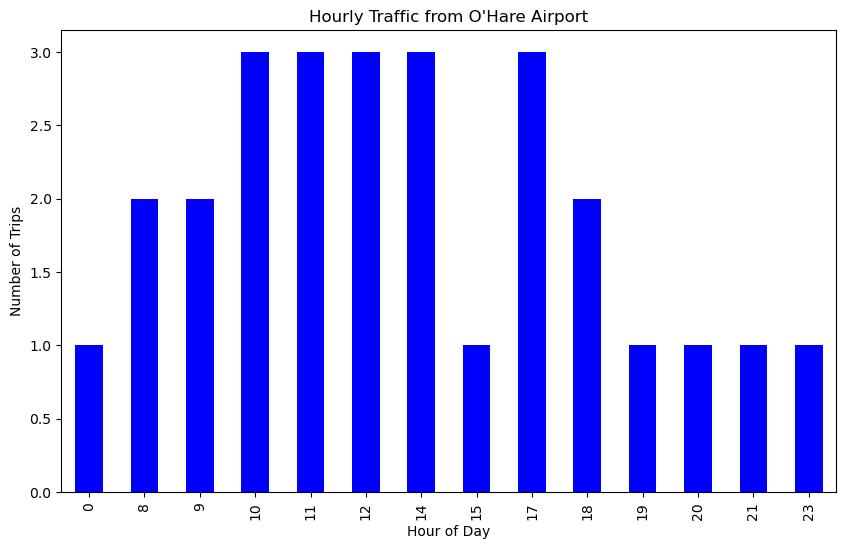

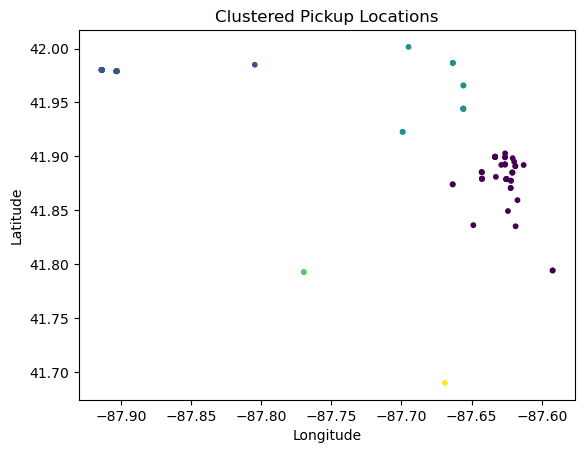

In [43]:
import folium
from folium.plugins import HeatMap
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
import time

# Load the dataset
file_path = "Taxi_Trips_2024.csv"
df = pd.read_csv(file_path)

# Sample some rows for testing
df_sample = df.sample(100, random_state=42)  # Sample 100 rows for faster testing

# Initialize geolocator for reverse geocoding
from geopy.geocoders import Nominatim
from geopy.exc import GeocoderTimedOut

geolocator = Nominatim(user_agent="geoapi")

# Reverse geocode function
def reverse_geocode(lat, lon):
    try:
        if pd.notna(lat) and pd.notna(lon):  # Ensure coordinates are not NaN
            time.sleep(1)  # Add delay to avoid rate limits
            location = geolocator.reverse((lat, lon), timeout=10)
            return location.address if location else None
        else:
            return None
    except GeocoderTimedOut:
        return None

# Reverse geocode pickup and dropoff addresses
df_sample['Pickup Address'] = df_sample.apply(
    lambda row: reverse_geocode(row['Pickup Centroid Latitude'], row['Pickup Centroid Longitude']), axis=1
)

df_sample['Dropoff Address'] = df_sample.apply(
    lambda row: reverse_geocode(row['Dropoff Centroid Latitude'], row['Dropoff Centroid Longitude']), axis=1
)

# Display a sample of geocoded data
print(df_sample[['Pickup Centroid Latitude', 'Pickup Centroid Longitude', 'Pickup Address', 
                 'Dropoff Centroid Latitude', 'Dropoff Centroid Longitude', 'Dropoff Address']].head())

# --- 1. Heatmap of Pickup Locations ---
m = folium.Map(location=[41.8781, -87.6298], zoom_start=11)  # Centered on Chicago

# Prepare data for heatmap (pickup coordinates)
heatmap_data = df_sample[['Pickup Centroid Latitude', 'Pickup Centroid Longitude']].dropna().values.tolist()

# Add a heatmap layer
HeatMap(heatmap_data, radius=10).add_to(m)

# Save or display the map
m.save('heatmap_pickup.html')


# --- 2. Flow Map (Pickup to Dropoff Connections) ---
for _, row in df_sample.iterrows():
    if pd.notna(row['Pickup Centroid Latitude']) and pd.notna(row['Dropoff Centroid Latitude']):
        folium.PolyLine(
            [(row['Pickup Centroid Latitude'], row['Pickup Centroid Longitude']),
             (row['Dropoff Centroid Latitude'], row['Dropoff Centroid Longitude'])],
            color="blue", weight=1, opacity=0.5
        ).add_to(m)

# Save or display the map
m.save('flow_map.html')


# --- 3. Top Locations by Address (Pickup Address) ---
top_pickup_addresses = df_sample['Pickup Address'].value_counts().head(10)

# Plot a bar chart
plt.figure(figsize=(10, 6))
top_pickup_addresses.plot(kind='barh', color='skyblue')
plt.title('Top 10 Pickup Locations')
plt.xlabel('Number of Trips')
plt.ylabel('Pickup Address')
plt.gca().invert_yaxis()  # Invert y-axis for better readability
plt.show()


# --- 4. Pickup vs. Dropoff Location Match ---
common_routes = df_sample.groupby(['Pickup Address', 'Dropoff Address']).size().reset_index(name='Count')
top_routes = common_routes.nlargest(10, 'Count')

# Plot a bar chart for the most frequent (pickup, dropoff) pairs
plt.figure(figsize=(12, 8))
sns.barplot(data=top_routes, x='Count', y='Pickup Address', hue='Dropoff Address')
plt.title('Top 10 Pickup-Dropoff Pairs')
plt.xlabel('Number of Trips')
plt.ylabel('Pickup Address')
plt.legend(title='Dropoff Address', loc='upper right')
plt.show()


# --- 5. Temporal Trends for Specific Locations (e.g., O'Hare) ---
# Filter trips to/from a specific location (e.g., O'Hare)
ohare_pickups = df_sample[df_sample['Pickup Address'].str.contains("O'Hare", na=False)]
ohare_pickups['Trip Hour'] = pd.to_datetime(df_sample['Trip Start Timestamp']).dt.hour

# Plot hourly distribution for O'Hare
ohare_pickups['Trip Hour'].value_counts().sort_index().plot(kind='bar', figsize=(10, 6), color='blue')
plt.title("Hourly Traffic from O'Hare Airport")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Trips")
plt.show()


# --- 6. Cluster Analysis of Geocoded Locations ---
# Prepare pickup coordinates for clustering
coordinates = df_sample[['Pickup Centroid Latitude', 'Pickup Centroid Longitude']].dropna()

# Perform clustering using KMeans
kmeans = KMeans(n_clusters=5, random_state=42).fit(coordinates)
coordinates['Cluster'] = kmeans.labels_

# Plot clusters
plt.scatter(coordinates['Pickup Centroid Longitude'], coordinates['Pickup Centroid Latitude'], 
            c=coordinates['Cluster'], cmap='viridis', s=10)
plt.title('Clustered Pickup Locations')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()

In [44]:
# Function to truncate address to first 5 words
def truncate_address(address, word_limit=5):
    return ' '.join(address.split()[:word_limit]) + '...' if address else 'Unknown'

# Apply the truncation to Pickup and Dropoff addresses
df_sample['Short Pickup Address'] = df_sample['Pickup Address'].apply(truncate_address)
df_sample['Short Dropoff Address'] = df_sample['Dropoff Address'].apply(truncate_address)

# Display the sample of shortened addresses
print(df_sample[['Pickup Address', 'Short Pickup Address', 'Dropoff Address', 'Short Dropoff Address']].head())

                                            Pickup Address  \
6440574  O'Hare Arrivals Terminal 3, O'Hare, Chicago, J...   
3573030  Moody Bible Institute, 820, North LaSalle Driv...   
61009    156, North Jefferson Street, Fulton River Dist...   
4964379  156, North Jefferson Street, Fulton River Dist...   
4735605  Simpson Querrey Biomedical Research Center, 30...   

                                   Short Pickup Address  \
6440574          O'Hare Arrivals Terminal 3, O'Hare,...   
3573030            Moody Bible Institute, 820, North...   
61009            156, North Jefferson Street, Fulton...   
4964379          156, North Jefferson Street, Fulton...   
4735605  Simpson Querrey Biomedical Research Center,...   

                                           Dropoff Address  \
6440574  Rush-Ohio-Wabash Self Park, 50, East Ohio Stre...   
3573030  4501-4503, South Calumet Avenue, Forestville, ...   
61009    Northern Trust Bank, 50, South La Salle Street...   
4964379  Chicago Midway 

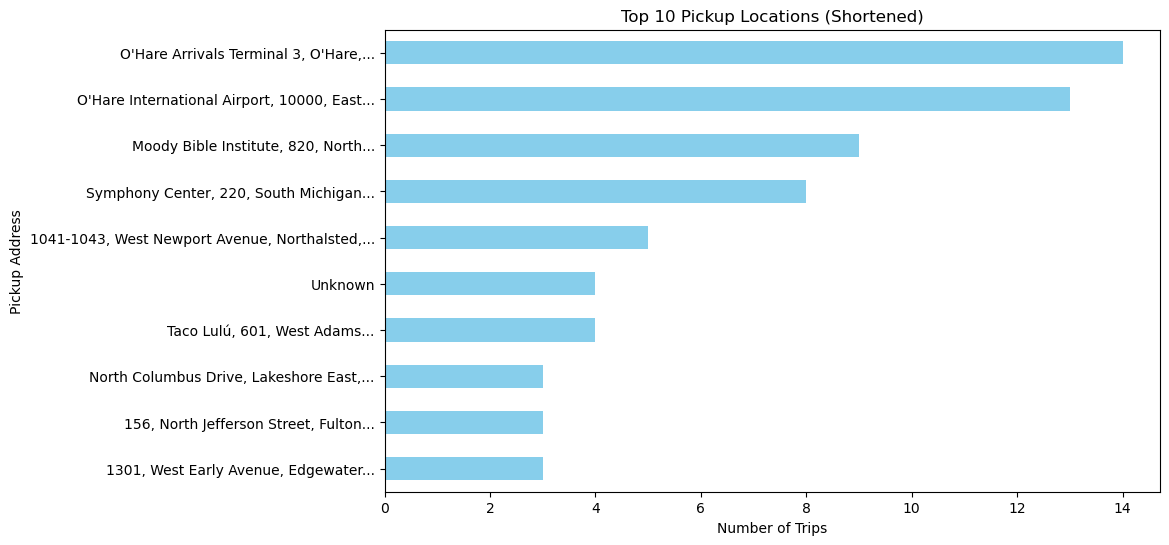

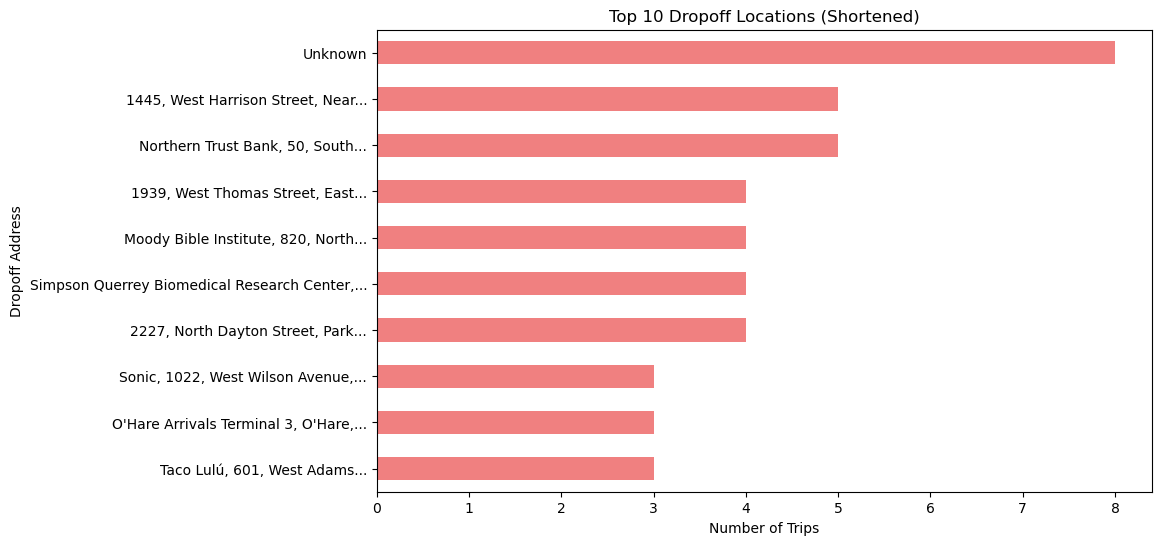

In [45]:
# Plot for top pickup locations (using shortened addresses)
top_pickup_addresses = df_sample['Short Pickup Address'].value_counts().head(10)

plt.figure(figsize=(10, 6))
top_pickup_addresses.plot(kind='barh', color='skyblue')
plt.title('Top 10 Pickup Locations (Shortened)')
plt.xlabel('Number of Trips')
plt.ylabel('Pickup Address')
plt.gca().invert_yaxis()  # Invert y-axis for better readability
plt.show()

# Plot for top dropoff locations (using shortened addresses)
top_dropoff_addresses = df_sample['Short Dropoff Address'].value_counts().head(10)

plt.figure(figsize=(10, 6))
top_dropoff_addresses.plot(kind='barh', color='lightcoral')
plt.title('Top 10 Dropoff Locations (Shortened)')
plt.xlabel('Number of Trips')
plt.ylabel('Dropoff Address')
plt.gca().invert_yaxis()  # Invert y-axis for better readability
plt.show()

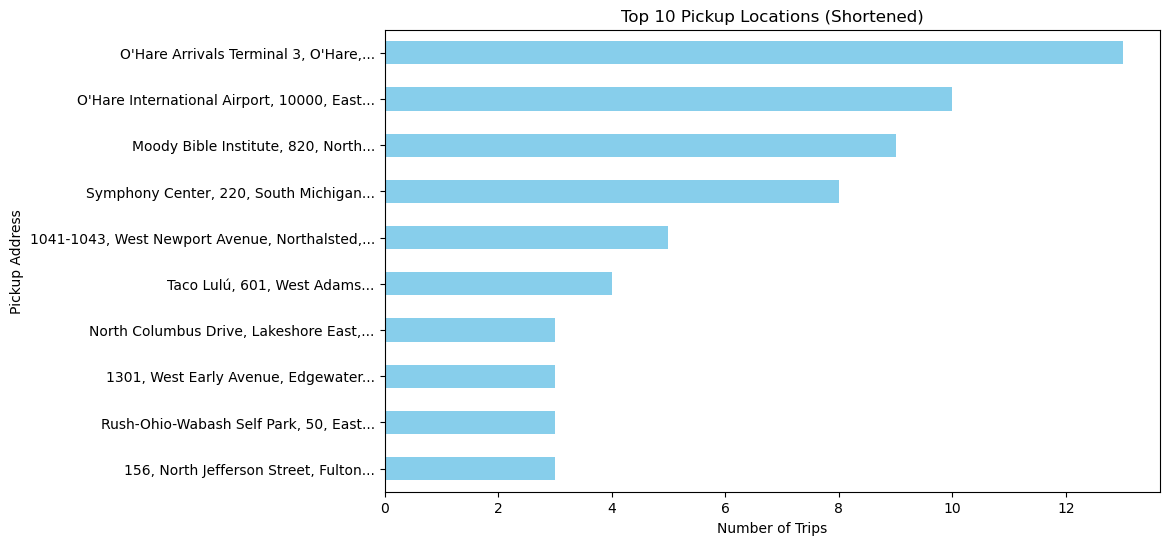

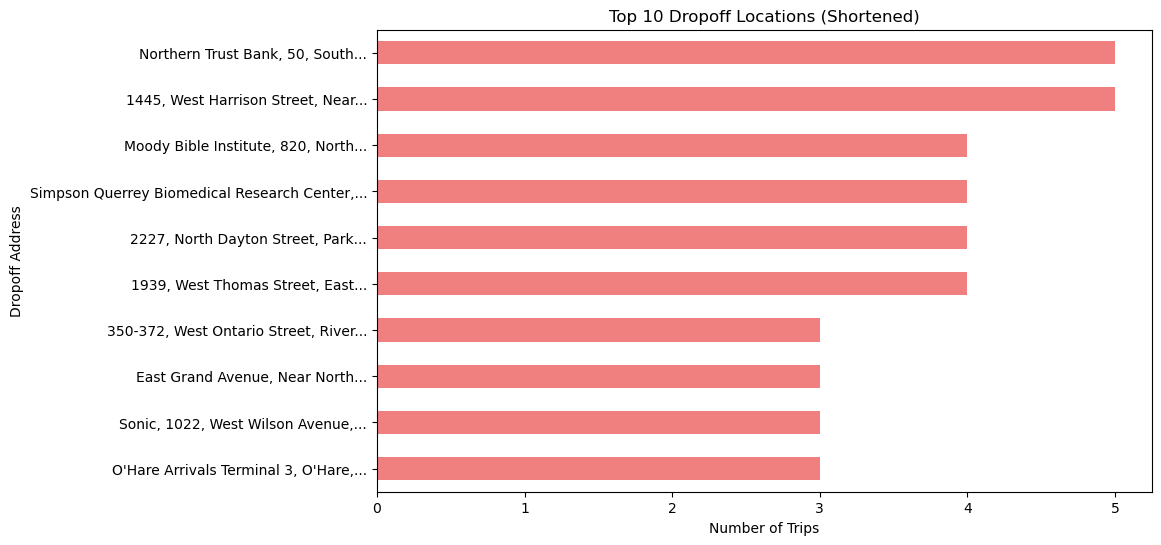

In [46]:
# Filter out rows where the Pickup or Dropoff address is "Unknown"
df_sample = df_sample[df_sample['Short Pickup Address'] != 'Unknown']
df_sample = df_sample[df_sample['Short Dropoff Address'] != 'Unknown']

# Now, plot the bar chart again using the cleaned dataset
top_pickup_addresses = df_sample['Short Pickup Address'].value_counts().head(10)

# Plot for top pickup locations (using shortened addresses)
plt.figure(figsize=(10, 6))
top_pickup_addresses.plot(kind='barh', color='skyblue')
plt.title('Top 10 Pickup Locations (Shortened)')
plt.xlabel('Number of Trips')
plt.ylabel('Pickup Address')
plt.gca().invert_yaxis()  # Invert y-axis for better readability
plt.show()

# Plot for top dropoff locations (using shortened addresses)
top_dropoff_addresses = df_sample['Short Dropoff Address'].value_counts().head(10)

plt.figure(figsize=(10, 6))
top_dropoff_addresses.plot(kind='barh', color='lightcoral')
plt.title('Top 10 Dropoff Locations (Shortened)')
plt.xlabel('Number of Trips')
plt.ylabel('Dropoff Address')
plt.gca().invert_yaxis()  # Invert y-axis for better readability
plt.show()

In [47]:
sampled_df.head()

,Trip ID,Taxi ID,Trip Start Timestamp,Trip End Timestamp,Trip Seconds,Trip Miles,Pickup Census Tract,Dropoff Census Tract,Pickup Community Area,Dropoff Community Area,...,Company,Pickup Centroid Latitude,Pickup Centroid Longitude,Pickup Centroid Location,Dropoff Centroid Latitude,Dropoff Centroid Longitude,Dropoff Centroid Location,Trip Status,Trip Duration (minutes),Trip Start Hour
1,612627f220ded19f3ae4b7c6dbd26fa2c8a37b3d,4634e511c40f4d1617cc543347c17518b98aed2fcde089...,2024-08-08 12:00:00,08/08/2024 12:15:00 PM,1335.0,8.87,0.000000e+00,0.000000e+00,8.0,38.0,...,sun taxi,41.899602,-87.633308,POINT (-87.6333080367 41.899602111),41.812949,-87.617860,POINT (-87.6178596758 41.8129489392),Completed,22.250000,12
2,2627be22855e4166a400de221b9eea0148805fb7,2bb06b59bdb626b7fbfb66f8a453fce2e6225e980c882f...,2024-01-18 08:00:00,01/18/2024 08:00:00 AM,450.0,1.10,1.703128e+10,1.703184e+10,28.0,32.0,...,taxi affiliation services llc - yell,41.885300,-87.642808,POINT (-87.6428084655 41.8853000224),41.880994,-87.632746,POINT (-87.6327464887 41.8809944707),Completed,7.500000,8
3,3e30e2876eadf0b1cef8a7c7218ff12e8cceb627,389f01c14b097ed951468ff163ccc71ebcb99a27e523e9...,2024-10-18 09:15:00,10/18/2024 09:45:00 AM,1540.0,11.15,1.703128e+10,1.703198e+10,28.0,56.0,...,medallion leasin,41.885300,-87.642808,POINT (-87.6428084655 41.8853000224),41.785999,-87.750934,POINT (-87.7509342894 41.785998518),Completed,25.666667,9
4,d9a80137497550896d4531e6e74399f3d2958f85,e829f46ff837c26216299fcead9868938026c1dc0e89c0...,2024-09-23 09:45:00,09/23/2024 09:45:00 AM,461.0,1.67,1.703108e+10,1.703128e+10,8.0,28.0,...,city service,41.895033,-87.619711,POINT (-87.6197106717 41.8950334495),41.885300,-87.642808,POINT (-87.6428084655 41.8853000224),Completed,7.683333,9
5,0848f0bad4841646c53b8c37dd880f5fdfa0cd2e,b5e2695a2f44b9bce7a0a86148ac418802f0067be1f6d4...,2024-12-05 13:30:00,12/05/2024 01:45:00 PM,723.0,6.56,0.000000e+00,0.000000e+00,8.0,77.0,...,sun taxi,41.899602,-87.633308,POINT (-87.6333080367 41.899602111),41.986712,-87.663416,POINT (-87.6634164054 41.9867117999),Completed,12.050000,13


In [48]:
sampled_df.dtypes

Trip ID                               object
Taxi ID                               object
Trip Start Timestamp          datetime64[ns]
Trip End Timestamp                    object
Trip Seconds                         float64
Trip Miles                           float64
Pickup Census Tract                  float64
Dropoff Census Tract                 float64
Pickup Community Area                float64
Dropoff Community Area               float64
Fare                                 float64
Tips                                 float64
Tolls                                float64
Extras                               float64
Trip Total                           float64
Payment Type                          object
Company                               object
Pickup Centroid Latitude             float64
Pickup Centroid Longitude            float64
Pickup Centroid Location              object
Dropoff Centroid Latitude            float64
Dropoff Centroid Longitude           float64
Dropoff Ce

In [49]:
sampled_df.to_csv("Taxi_Trips_2024_Transformed.csv", index=False)

In [50]:
sampled_df.shape

(1105495, 26)

In [51]:
from sqlalchemy import create_engine
import pandas as pd

# Replace these variables with your actual MySQL connection details
username = 'root'
password = '****'
host = 'localhost'
port = 3306
database = 'taxi_dw'

# Create the connection engine
engine = create_engine(f'mysql+mysqlconnector://{username}:{password}@{host}:{port}/{database}')

# Test connection by listing tables (optional)
with engine.connect() as connection:
    tables = connection.execute("SHOW TABLES;").fetchall()
    print("Existing tables:", tables)

Existing tables: [('location_dim',), ('taxi_trips',), ('taxi_trips_fact',), ('time_dim',)]


In [52]:
# Read the transformed dataset. Adjust the date parsing as needed.
transformed_df = pd.read_csv('Taxi_Trips_2024_Transformed.csv')

chunksize = 1000
transformed_df.to_sql('taxi_trips', con=engine, if_exists='append', index=False, chunksize = chunksize)
print("Data loaded")

Data loaded


In [53]:
transformed_df.columns

Index(['Trip ID', 'Taxi ID', 'Trip Start Timestamp', 'Trip End Timestamp',
       'Trip Seconds', 'Trip Miles', 'Pickup Census Tract',
       'Dropoff Census Tract', 'Pickup Community Area',
       'Dropoff Community Area', 'Fare', 'Tips', 'Tolls', 'Extras',
       'Trip Total', 'Payment Type', 'Company', 'Pickup Centroid Latitude',
       'Pickup Centroid Longitude', 'Pickup Centroid Location',
       'Dropoff Centroid Latitude', 'Dropoff Centroid Longitude',
       'Dropoff Centroid Location', 'Trip Status', 'Trip Duration (minutes)',
       'Trip Start Hour'],
      dtype='object')

In [54]:
# Convert 'Trip Start Timestamp' to datetime format
transformed_df['Trip Start Timestamp'] = pd.to_datetime(transformed_df['Trip Start Timestamp'])

# Create a DataFrame for the time dimension from the fact table data
transformed_df['Trip_Date'] = transformed_df['Trip Start Timestamp'].dt.date
transformed_df['Trip_Hour'] = transformed_df['Trip Start Timestamp'].dt.hour
transformed_df['Day_Of_Week'] = transformed_df['Trip Start Timestamp'].dt.day_name()
transformed_df['Month'] = transformed_df['Trip Start Timestamp'].dt.month
transformed_df['Year'] = transformed_df['Trip Start Timestamp'].dt.year

time_dim_df = transformed_df[['Trip_Date', 'Trip_Hour', 'Day_Of_Week', 'Month', 'Year']].drop_duplicates()

# Load into the MySQL table 'time_dim'
time_dim_df.to_sql('time_dim', con=engine, if_exists='append', index=False)
print("Time dimension populated.")

Time dimension populated.


In [55]:
# Step 1: Prepare pickup location data
pickup_location_df = transformed_df[
    [
        'Pickup Community Area', 
        'Pickup Census Tract',
        'Pickup Centroid Latitude',
        'Pickup Centroid Longitude',
        'Pickup Centroid Location'
    ]
].drop_duplicates()

# Rename columns (including Pickup Centroid Location -> Location_Description)
pickup_location_df = pickup_location_df.rename(columns={
    'Pickup Community Area': 'Community_Area',
    'Pickup Census Tract': 'Census_Tract',
    'Pickup Centroid Latitude': 'Centroid_Latitude',
    'Pickup Centroid Longitude': 'Centroid_Longitude',
    'Pickup Centroid Location': 'Location_Description'  # <--- KEY CHANGE
})

# Step 2: Prepare dropoff location data
dropoff_location_df = transformed_df[
    [
        'Dropoff Community Area', 
        'Dropoff Census Tract',
        'Dropoff Centroid Latitude',
        'Dropoff Centroid Longitude',
        'Dropoff Centroid Location'
    ]
].drop_duplicates()

# Rename columns (including Dropoff Centroid Location -> Location_Description)
dropoff_location_df = dropoff_location_df.rename(columns={
    'Dropoff Community Area': 'Community_Area',
    'Dropoff Census Tract': 'Census_Tract',
    'Dropoff Centroid Latitude': 'Centroid_Latitude',
    'Dropoff Centroid Longitude': 'Centroid_Longitude',
    'Dropoff Centroid Location': 'Location_Description'  # <--- KEY CHANGE
})

# Step 3: Combine pickup and dropoff location data into a single DataFrame
location_df = pd.concat([pickup_location_df, dropoff_location_df]).drop_duplicates()

# Step 4: Load into MySQL table 'location_dim'
location_df.to_sql('location_dim', con=engine, if_exists='append', index=False)
print("Location dimension populated.")

Location dimension populated.
